# 4_Word Embeddings

In this notebook, we study word embeddings in order to better understand the semantic structure of the review corpus.

We first train a Word2Vec model on the insurance reviews then explore similar words, compute distances between word vectors and visualize embeddings in 2D.

We also compare these learned embeddings with pre trained embeddings such as Glove.

Imports

In [1]:
%pip install gensim

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import gensim
from gensim.models import Word2Vec
import gensim.downloader as api

%pip install nltk

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

Note: you may need to restart the kernel to use updated packages.


/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Note: you may need to restart the kernel to use updated packages.


Load the dataset

In [2]:
df = pd.read_csv("../data/processed/reviews_clean.csv")

df.shape

(34433, 14)

### 1- Prepare text for embeddings

Before training Word2Vec, we need to transform each review into a list of tokens.
This step is important because Word2Vec learns word representations by looking at the context in which words appear across the corpus.

- Download NLTK

In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/koralie/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/koralie/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/koralie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

- French stopwords

In [4]:
french_stopwords = set(stopwords.words("french"))
french_stopwords = french_stopwords - {"pas", "ne", "jamais"} # keep important negation words

- Tokenization fucntion

In [5]:
def tokenize_text(text): # tokenize and remove stopwords
    tokens = word_tokenize(str(text).lower(), language="french") 
    tokens = [t for t in tokens if t.isalpha()]# isalpha keep only alphabetic tokens
    tokens = [t for t in tokens if t not in french_stopwords] 
    return tokens

- Create tokenized corpus

In [6]:
sentences = df["avis_clean"].dropna().apply(tokenize_text).tolist()
sentences[:2]

[['quitté',
  'ancien',
  'contrat',
  'assurance',
  'chez',
  'générali',
  'année',
  'derniere',
  'rejoindre',
  'groupe',
  'néoliane',
  'peux',
  'dire',
  'maitnenant',
  'après',
  'an',
  'seule',
  'chose',
  'change',
  'prix',
  'assuré',
  'façon',
  'pourtant',
  'paye',
  'moins',
  'mois',
  'uqi',
  'an',
  'fait',
  'économiser',
  'fortune',
  'donc',
  'resté',
  'assuré',
  'aujourd',
  'hui',
  'chez',
  'prouve',
  'bien',
  'seule',
  'chose',
  'gagnons',
  'hausses',
  'cotisations',
  'marre',
  'payer'],
 ['souscrit',
  'cette',
  'mutuelle',
  'année',
  'derniere',
  'restée',
  'an',
  'trouvé',
  'formule',
  'très',
  'avantageuse',
  'car',
  'tarif',
  'très',
  'intéressant',
  'lentilles',
  'lunettes',
  'pris',
  'décision',
  'changer',
  'car',
  'besoin',
  'orthodoncie',
  'ne',
  'pas',
  'contre',
  'formule',
  'précédente']]

- Verification

In [7]:
print("Number of tokenized reviews:", len(sentences))
print("Example tokens:", sentences[0][:20])

Number of tokenized reviews: 34433
Example tokens: ['quitté', 'ancien', 'contrat', 'assurance', 'chez', 'générali', 'année', 'derniere', 'rejoindre', 'groupe', 'néoliane', 'peux', 'dire', 'maitnenant', 'après', 'an', 'seule', 'chose', 'change', 'prix']


### 2-Train Word2vec

Word2Vec learns a dense vector representation for each word based on its context in the corpus.
Words that appear in similar contexts tend to have similar vector representations.

In [8]:
word2vec_model = Word2Vec(sentences=sentences,vector_size=100,window=5,min_count=5,workers=4,sg=1) #window=5 means we look at a context of 5 words around the target word, min_count=5 means we ignore words that appear less than 5 times, sg=1 means we use skip-gram 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


- Vocabulary check

In [9]:
len(word2vec_model.wv.index_to_key)

10228

- Some words of the vocabulary

In [10]:
word2vec_model.wv.index_to_key[:20]

['pas',
 'a',
 'assurance',
 'ne',
 'très',
 'plus',
 'service',
 'prix',
 'bien',
 'contrat',
 'tout',
 'depuis',
 'mois',
 'cette',
 'fait',
 'satisfait',
 'chez',
 'faire',
 'sans',
 'sinistre']

### 3-Most similar words

Once the model is trained, we can inspect the nearest words in the embedding space.
This helps us verify whether the model has captured meaningful semantic relationships.

In [12]:
word2vec_model.wv.most_similar("sinistre", topn=10) 

[('sinistres', 0.7273371815681458),
 ('accident', 0.7176828980445862),
 ('litige', 0.7140567898750305),
 ('sinitre', 0.7104202508926392),
 ('pépin', 0.6767560243606567),
 ('dégât', 0.6766444444656372),
 ('incidents', 0.6702218651771545),
 ('accrochage', 0.6680973768234253),
 ('pepin', 0.6645979285240173),
 ('dégat', 0.6601928472518921)]

In [13]:
for word in ["prix", "service", "client", "remboursement", "assurance"]:
    if word in word2vec_model.wv:
        print(f"\nMost similar words to '{word}':")
        print(word2vec_model.wv.most_similar(word, topn=10))


Most similar words to 'prix':
[('tarif', 0.8572312593460083), ('tarifs', 0.8232020139694214), ('proposez', 0.7476630806922913), ('tarification', 0.7251853942871094), ('couteuse', 0.7232313752174377), ('moyennement', 0.7179122567176819), ('concurence', 0.7176980972290039), ('restes', 0.7175830602645874), ('convienne', 0.7097752690315247), ('offrent', 0.7082698345184326)]

Most similar words to 'service':
[('sav', 0.7005161046981812), ('services', 0.6873791813850403), ('support', 0.6837628483772278), ('servie', 0.6836206316947937), ('performant', 0.6808096170425415), ('genial', 0.6801460981369019), ('clientele', 0.676937460899353), ('reactif', 0.6718578338623047), ('process', 0.6703525185585022), ('irréprochable', 0.6692969799041748)]

Most similar words to 'client':
[('clientèle', 0.7815055847167969), ('abonné', 0.6805955171585083), ('clients', 0.6792757511138916), ('clientele', 0.6587058305740356), ('personnel', 0.6436411738395691), ('désastreux', 0.6359483003616333), ('médiocre', 0.6

### 4- Cosine similarity and euclidean distance

To compare word vectors, we use similarity and distance measures.

- Cosine similarity measures how aligned two vectors are.
- Euclidean distance measures how far apart two vectors are in space.

These metrics help quantify semantic proximity between words.

In [14]:
def compare_words(word1, word2, model):
    if word1 in model.wv and word2 in model.wv: 
        vec1 = model.wv[word1].reshape(1, -1)
        vec2 = model.wv[word2].reshape(1, -1)
        
        cos_sim = cosine_similarity(vec1, vec2)[0][0]
        euc_dist = euclidean(vec1.flatten(), vec2.flatten())
        
        print(f"Words: {word1} / {word2}")
        print(f"Cosine similarity: {cos_sim:.4f}")
        print(f"Euclidean distance: {euc_dist:.4f}")
    else:
        print("One of the words is not in the vocabulary.")

Examples

In [15]:
compare_words("prix", "tarif", word2vec_model)
compare_words("service", "client", word2vec_model)
compare_words("bon", "mauvais", word2vec_model)

Words: prix / tarif
Cosine similarity: 0.8572
Euclidean distance: 1.7893
Words: service / client
Cosine similarity: 0.5567
Euclidean distance: 2.8308
Words: bon / mauvais
Cosine similarity: 0.6644
Euclidean distance: 2.5411


### 5-Visualization of embeddings

To better understand the structure of the embedding space, we project a subset of word vectors into two dimensions.
This allows us to visually inspect whether semantically related words form clusters.

In [16]:
selected_words = ["prix", "tarif", "augmentation", "service", "client","sinistre", "remboursement", "contrat", "voiture", "moto",
    "satisfait", "mauvais", "problème", "rapide", "retard"]

selected_words = [w for w in selected_words if w in word2vec_model.wv]
selected_words

['prix',
 'tarif',
 'augmentation',
 'service',
 'client',
 'sinistre',
 'remboursement',
 'contrat',
 'voiture',
 'moto',
 'satisfait',
 'mauvais',
 'problème',
 'rapide',
 'retard']

- Extract some vectors

In [17]:
word_vectors = np.array([word2vec_model.wv[word] for word in selected_words])

- PCA simple version

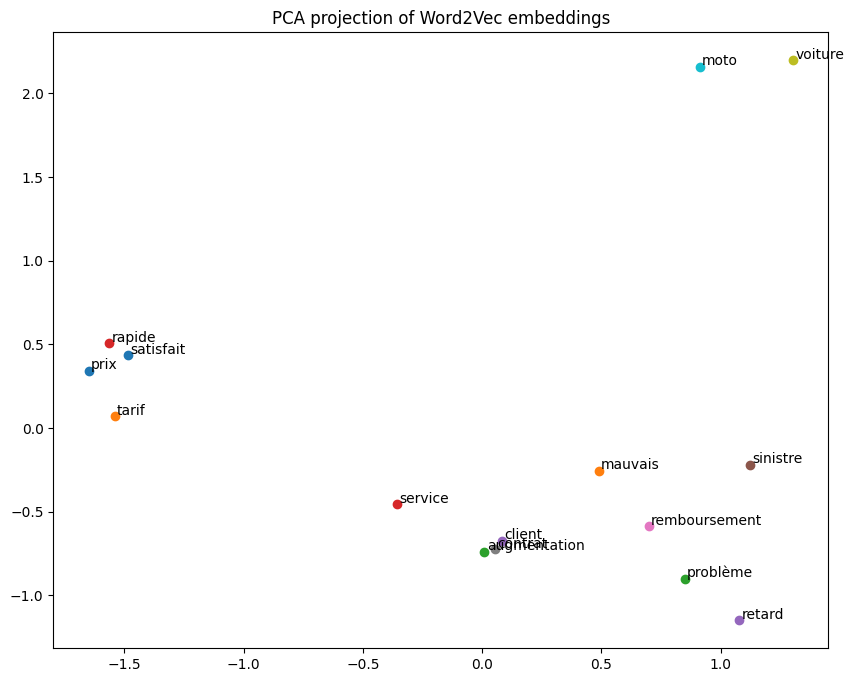

In [18]:
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
for i, word in enumerate(selected_words):
    plt.scatter(coords[i, 0], coords[i, 1])
    plt.text(coords[i, 0] + 0.01, coords[i, 1] + 0.01, word, fontsize=10)

plt.title("PCA projection of Word2Vec embeddings")
plt.show()

- t-SNE more visual version

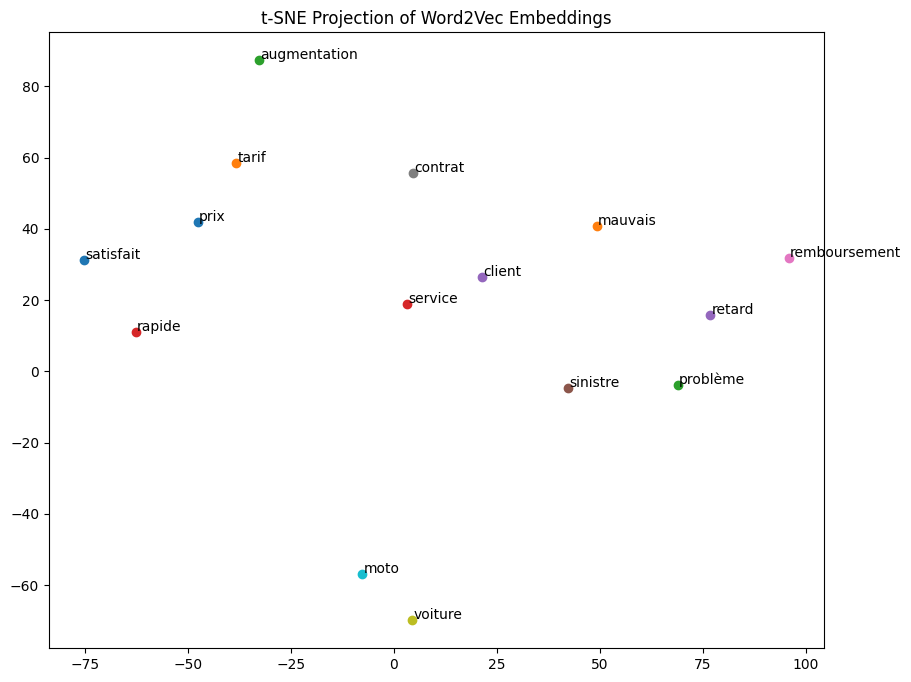

In [19]:
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(selected_words)-1))
coords_tsne = tsne.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
for i, word in enumerate(selected_words):
    plt.scatter(coords_tsne[i, 0], coords_tsne[i, 1])
    plt.text(coords_tsne[i, 0] + 0.3, coords_tsne[i, 1] + 0.3, word, fontsize=10)

plt.title("t-SNE Projection of Word2Vec Embeddings")
plt.show()

- Tensorboard

While PCA and t-SNE provide static visualizations of the embedding space, we now use TensorBoard projector to explore embeddings interactively.

Download Tensorflow

In [26]:
%pip install tensorflow tensorboard

Note: you may need to restart the kernel to use updated packages.


Imports

In [ ]:
import os
import io
import tensorflow as tf
from tensorboard.plugins import projector

Create a logs folder

In [ ]:
log_dir = "../models/tensorboard_word2vec"
os.makedirs(log_dir, exist_ok=True)

Select some words

In [ ]:
vocab_words = word2vec_model.wv.index_to_key[:500]
embedding_vectors = np.array([word2vec_model.wv[word] for word in vocab_words])

Create the variable Tensorflow

In [ ]:
embedding_var = tf.Variable(embedding_vectors, name="word2vec_embeddings")
checkpoint = tf.train.Checkpoint(embedding=embedding_var)
checkpoint.save(os.path.join(log_dir, "embedding.ckpt"))

Create metadata file

TensorBoard needs a file which contains the words associated to the vectors. 

In [ ]:
metadata_path = os.path.join(log_dir, "metadata.tsv")

with open(metadata_path, "w", encoding="utf-8") as f:
    for word in vocab_words:
        f.write(word + "\n")

Configurate TensorBoard projector 

In [ ]:
config = projector.ProjectorConfig()
embedding = config.embeddings.add()
embedding.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
embedding.metadata_path = "metadata.tsv"

projector.visualize_embeddings(log_dir, config)

Launch Tensorboard 

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ../models/tensorboard_word2vec

In [ ]:
#tensorboard --logdir models/tensorboard_word2vec

TensorBoard provides an interactive visualization of the Word2Vec embedding space.  
This makes it possible to inspect clusters of semantically related words and complements the static PCA/t-SNE visualizations shown above.

### 6- GloVe embeddings

In addition to embeddings trained on our own corpus, we can also use pre trained embeddings such as GloVe.
This comparison helps us understand the difference between corpus specific embeddings and general purpose embeddings.

- Upload GloVe

In [20]:
glove_model = api.load("glove-wiki-gigaword-100")

- Similar words with Glove

In [21]:
for word in ["price", "service", "customer", "car", "insurance"]:
    if word in glove_model:
        print(f"\nMost similar words to '{word}' in GloVe:")
        print(glove_model.most_similar(word, topn=10))


Most similar words to 'price' in GloVe:
[('prices', 0.8554711937904358), ('value', 0.760714054107666), ('drop', 0.7485077381134033), ('stock', 0.7451035380363464), ('market', 0.7407819628715515), ('sales', 0.736183226108551), ('cost', 0.72527676820755), ('higher', 0.7221201062202454), ('share', 0.7172418236732483), ('rise', 0.7157853841781616)]

Most similar words to 'service' in GloVe:
[('services', 0.8831207752227783), ('public', 0.6898016333580017), ('network', 0.6799494624137878), ('private', 0.6653395891189575), ('system', 0.663616955280304), ('business', 0.6610175967216492), ('provided', 0.6580187082290649), ('available', 0.6564439535140991), ('information', 0.6545517444610596), ('access', 0.653258204460144)]

Most similar words to 'customer' in GloVe:
[('customers', 0.8007058501243591), ('employee', 0.7166430950164795), ('user', 0.6752105355262756), ('business', 0.6595260500907898), ('phone', 0.6565642952919006), ('product', 0.6508812308311462), ('clients', 0.6461817622184753),

### 7- Semantic search

As a bonus, we implement a simple semantic search based on document embeddings.
For each review, we compute an average Word2Vec vector and retrieve the most similar reviews to a query.

- Function to calculate the mean of the emebeddings of a review

In [22]:
def average_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

- Review vector 

In [23]:
review_vectors = np.array([average_vector(tokens, word2vec_model) for tokens in sentences])

- search fucntion

In [24]:
def semantic_search(query, model, review_vectors, texts, top_k=5):
    query_tokens = tokenize_text(query)
    query_vec = average_vector(query_tokens, model).reshape(1, -1)
    
    sims = cosine_similarity(query_vec, review_vectors)[0]
    top_idx = sims.argsort()[-top_k:][::-1]
    
    results = [(texts[i], sims[i]) for i in top_idx]
    return results

- Test 

In [25]:
results = semantic_search("problème de remboursement et retard", word2vec_model, review_vectors, df["avis_clean"].dropna().tolist(), top_k=5)

for i, (review, score) in enumerate(results, 1):
    print(f"\nResult {i} - similarity: {score:.4f}")
    print(review[:300])


Result 1 - similarity: 0.8051
toujours des soucis des régularisations des indemnités non versées des dossiers égarés des soucis constamment alors que je suis en dépression et que ça n est déjà pas facile maintenant un remboursement énorme à leur faire par rapport à une re qualification bref à fuir je déconseille des délais incro

Result 2 - similarity: 0.8050
après difficulté de remboursement l4interlocuteur de santiane a résolut le problème rapidement

Result 3 - similarity: 0.7974
ou est le réel problème avec afer aucune nouvelle de votre part alors que vous avez plusieurs semaines de retard pour le versement d une assurance vie devons nous nous inquiéter et quid des pénalités de retard

Result 4 - similarity: 0.7932
très satisfait par mon correspondant en ligne qui as répondu à mes questions sur un problème de remboursement de consultation de médecin généraliste et as réglé un problème de passerelle sur le site ameli ou j étais bloqué

Result 5 - similarity: 0.7931
nous sommes le 1

### 8-Conclusion

In this notebook, we trained a Word2Vec model on the customer review corpus and used it to explore semantic relationships between words.
We also computed cosine similarity and euclidean distance, visualized the embedding space, and compared our corpus specific embeddings with pre trained GloVe vectors.
These embeddings provide a complementary view of the dataset and will be useful for understanding word semantics and supporting later NLP tasks.